# Семинар 2. Классификация и метрики качества

**План занятия:**

1. Метод $k$ ближайших соседей.
2. Логистическая регрессия и вероятностный выход.
3. Матрица ошибок, precision / recall / F1.
4. ROC-кривая, AUC и выбор порога.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
rng = np.random.default_rng(42)

## 1. Данные

Возьмём классический набор «Wisconsin breast cancer»: 30 числовых признаков,
бинарная целевая переменная (злокачественная / доброкачественная опухоль).

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

data = load_breast_cancer()
X, y = data.data, data.target

print("Размер выборки:", X.shape)
print("Баланс классов:", np.bincount(y), "(0 — злокачественная, 1 — доброкачественная)")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

Размер выборки: (569, 30)
Баланс классов: [212 357] (0 — злокачественная, 1 — доброкачественная)


## 2. kNN и логистическая регрессия

Метрические методы чувствительны к масштабу признаков, поэтому обязательно
ставим `StandardScaler` в пайплайн.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(X_tr, y_tr)
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_tr, y_tr)

for name, model in [("kNN (k=5)", knn), ("Логистическая регрессия", logreg)]:
    print(f"{name:24s} accuracy = {accuracy_score(y_te, model.predict(X_te)):.3f}")

kNN (k=5)                accuracy = 0.959
Логистическая регрессия  accuracy = 0.988


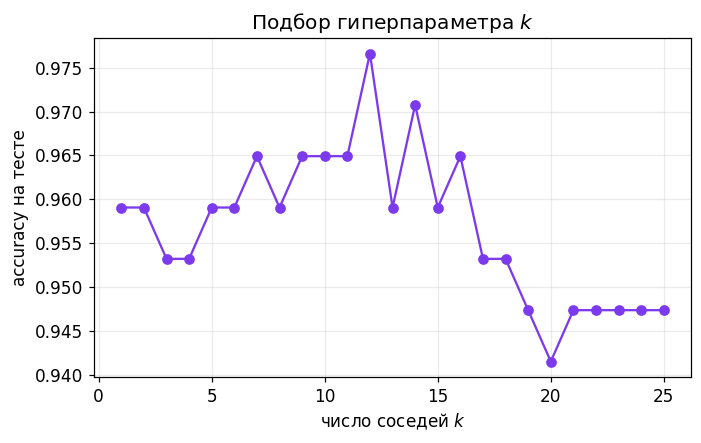

In [4]:
# Как качество kNN зависит от числа соседей
ks = range(1, 26)
scores = [make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
          .fit(X_tr, y_tr).score(X_te, y_te) for k in ks]

plt.plot(list(ks), scores, marker="o", color="#7c3aed")
plt.xlabel("число соседей $k$"); plt.ylabel("accuracy на тесте")
plt.title("Подбор гиперпараметра $k$")
plt.show()

## 3. Матрица ошибок

Accuracy обманчива при несбалансированных классах. Смотрим на матрицу ошибок
и производные метрики:

$$\text{precision} = \frac{TP}{TP + FP}, \qquad
  \text{recall} = \frac{TP}{TP + FN}, \qquad
  F_1 = \frac{2\,PR}{P + R}.$$

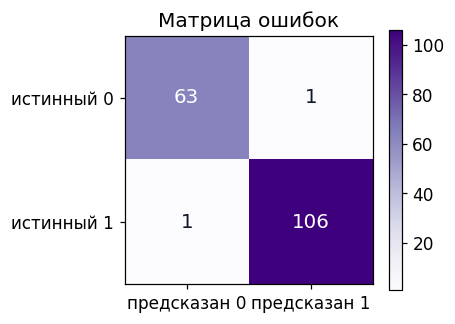

                   precision    recall  f1-score   support

  злокачественная       0.98      0.98      0.98        64
доброкачественная       0.99      0.99      0.99       107

         accuracy                           0.99       171
        macro avg       0.99      0.99      0.99       171
     weighted avg       0.99      0.99      0.99       171



In [5]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = logreg.predict(X_te)
cm = confusion_matrix(y_te, y_pred)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm, cmap="Purples")
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, value, ha="center", va="center",
            color="white" if value > cm.max() / 2 else "#0f172a", fontsize=13)
ax.set_xticks([0, 1], ["предсказан 0", "предсказан 1"])
ax.set_yticks([0, 1], ["истинный 0", "истинный 1"])
ax.grid(False)
ax.set_title("Матрица ошибок")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(classification_report(y_te, y_pred, target_names=["злокачественная", "доброкачественная"]))

## 4. ROC-кривая и выбор порога

Модель выдаёт вероятность; порог 0.5 — не догма. ROC-кривая показывает
компромисс между TPR и FPR при всех порогах сразу.

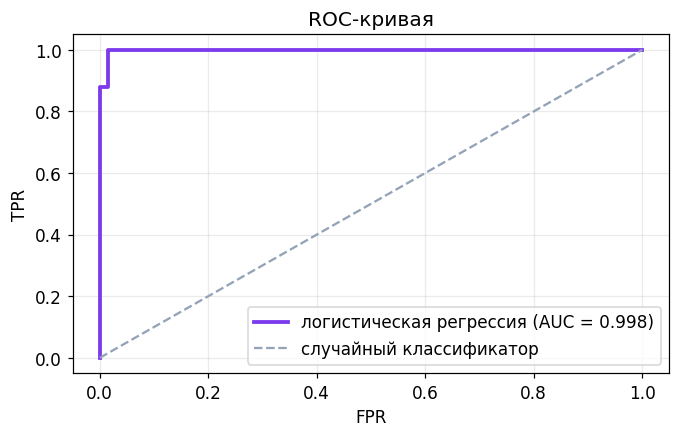

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

proba = logreg.predict_proba(X_te)[:, 1]
fpr, tpr, thresholds = roc_curve(y_te, proba)
auc = roc_auc_score(y_te, proba)

plt.plot(fpr, tpr, color="#7c3aed", lw=2.5, label=f"логистическая регрессия (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], ls="--", color="#94a3b8", label="случайный классификатор")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривая")
plt.legend(loc="lower right")
plt.show()

In [7]:
# Порог, максимизирующий F1
precision, recall, thr = precision_recall_curve(y_te, proba)
f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
best = np.nanargmax(f1[:-1])

print(f"Порог по умолчанию 0.50 -> F1 = {f1[np.searchsorted(thr, 0.5)]:.3f}")
print(f"Оптимальный порог {thr[best]:.2f} -> F1 = {f1[best]:.3f}")

Порог по умолчанию 0.50 -> F1 = 0.991
Оптимальный порог 0.37 -> F1 = 0.995


## Задание для самостоятельной работы

1. Постройте PR-кривую и объясните, чем она информативнее ROC при сильном дисбалансе классов.
2. Сравните `LogisticRegression` с `penalty='l1'` и `penalty='l2'`: сколько признаков остаётся?
3. Подберите `k` для kNN по кросс-валидации (`GridSearchCV`), а не по тестовой выборке.
   Почему второй способ — методологическая ошибка?